In [3]:
import pandas as pd
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sparse
from scipy.stats import pearsonr

from scipy.cluster.hierarchy import linkage
import scipy.spatial.distance as ssd

import seaborn as sns
import sys
from scipy.sparse import hstack, csr_matrix
from sklearn.feature_selection import mutual_info_classif
import os
# from cnmf import cNMF, save_df_to_npz, load_df_from_npz
# import harmonypy
# from adjustText import adjust_text

from matplotlib.patches import Patch
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.patches import Rectangle
from matplotlib.pyplot import rc_context

# UMAP Visualization

## Import Seurat Coords

In [4]:
umap_coords = pd.read_csv("../postTrans_v2/postTrans_coordinates.csv", index_col = 0)

In [5]:
print(umap_coords.head())

                                    umap_1    umap_2  cluster
A_A_AAACGCTTCACTTGTT_A_pos_A_pos -3.156499 -7.825476        3
A_A_AAAGGATCAATGCAGG_A_pos_A_pos  5.618103  0.757314        1
A_A_AAAGGATGTGCGAGTA_A_pos_A_pos -2.468250 -6.764936        3
A_A_AAAGGATTCACTGATG_A_pos_A_pos  4.657690 -0.200323        8
A_A_AAAGGGCCACCCTCTA_A_pos_A_pos -7.245675 -2.105738       23


## Plotting UMAP

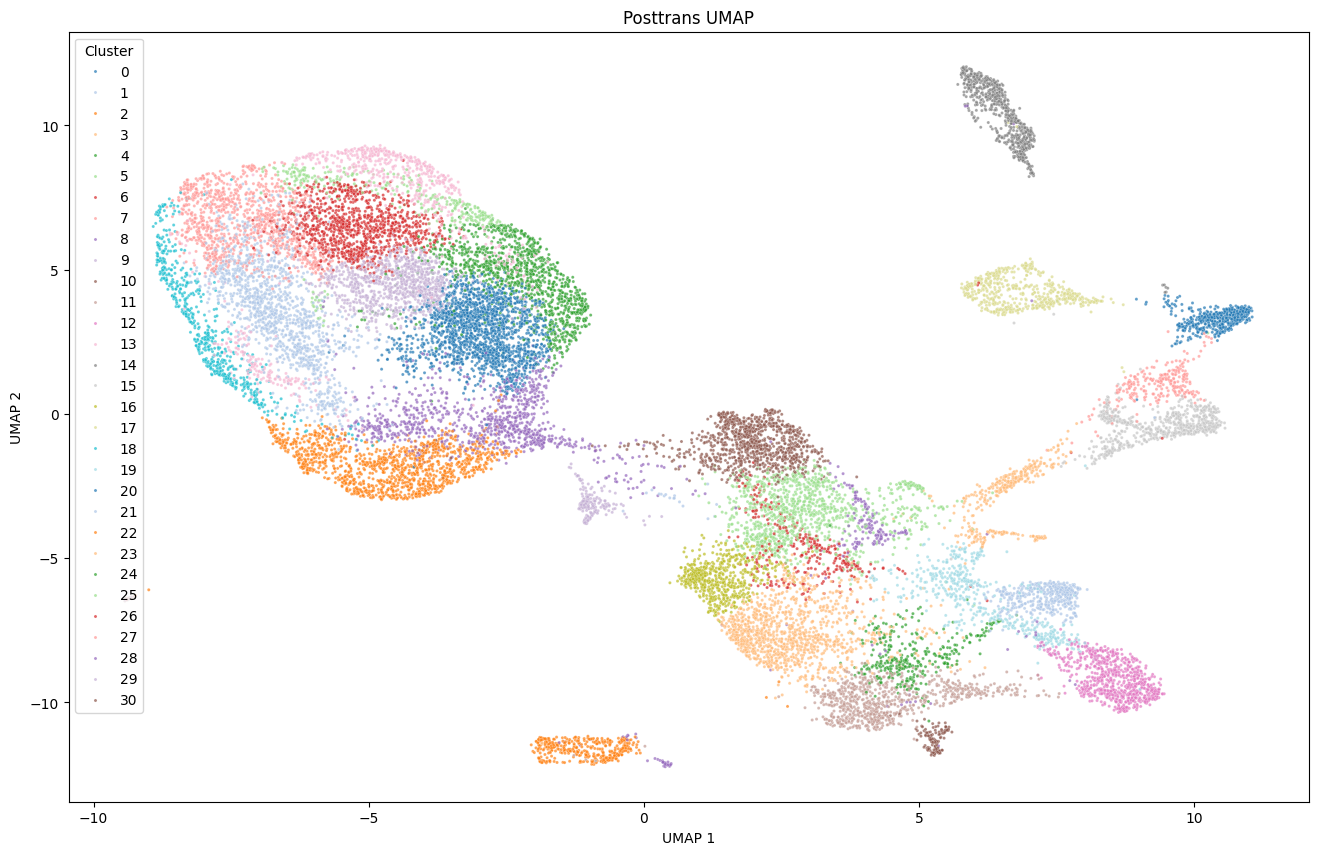

In [6]:
plt.figure(figsize=(16, 10))

sns.scatterplot(
    x=-umap_coords.iloc[:, 0], 
    y=umap_coords.iloc[:, 1], 
    hue=umap_coords["cluster"], 
    palette="tab20", 
    s=5, alpha=0.7
)

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("Posttrans UMAP")
plt.legend(title = "Cluster")
plt.show()

## UMAP w/ top 5% usage for each interest GEP

Interesting GEPs
- GEP1 – Monocyte Lineage
- GEP4 – Elderly-biased HSC
- GEP6 – Late-Erythroid Lineage
- GEP14 – Basophil/Mast Cell Lineage
- GEP25 – Dendritic Cell Lineage
- GEP26 – Lymphoid Lineage
- GEP28 – Fetal-biased HSC
- GEP30 – Granulocyte Lineage
- GEP32 – Erythroid Lineage

*taken from cols*

### Import starCAT usage scores

In [7]:
starCAT_usage = pd.read_csv("../postTrans_v2/seu_common_starCAT.rf_usage_normalized.txt", sep = "\t", index_col = 0, header = 0)

starCAT_usage

,1,2,3,4,5,6,7,8,9,10,...,26,27,28,29,30,31,32,33,34,35
A_A_AAACGCTTCACTTGTT_A_pos_A_pos,0.093233,0.002983,1.007881e-06,0.071942,3.168060e-07,1.104623e-05,2.729464e-05,1.530326e-02,2.887531e-05,4.225383e-05,...,0.041570,0.000314,5.617969e-03,4.715390e-03,0.162382,0.014679,0.001075,0.172153,0.005786,0.000963
A_A_AAAGGATCAATGCAGG_A_pos_A_pos,0.000019,0.024977,2.066610e-03,0.104109,4.819353e-03,1.020839e-05,5.619268e-07,8.505102e-03,1.025467e-05,1.577429e-05,...,0.007069,0.004421,3.998451e-04,1.298720e-04,0.001893,0.023042,0.087538,0.152262,0.000647,0.020365
A_A_AAAGGATGTGCGAGTA_A_pos_A_pos,0.050029,0.045443,1.854130e-06,0.097183,4.761867e-04,1.048743e-08,1.713639e-05,1.385657e-02,4.805190e-04,1.256192e-04,...,0.014255,0.027242,2.475501e-02,4.028279e-06,0.206693,0.019369,0.000562,0.002179,0.000879,0.000003
A_A_AAAGGATTCACTGATG_A_pos_A_pos,0.005042,0.007156,2.261943e-06,0.160692,5.459796e-04,1.103508e-03,5.911876e-09,2.269140e-03,5.826896e-06,4.155051e-07,...,0.014653,0.012651,4.264442e-09,4.316421e-05,0.000583,0.027664,0.095605,0.004965,0.000003,0.004142
A_A_AAAGGGCCACCCTCTA_A_pos_A_pos,0.017922,0.009738,2.513232e-08,0.084618,2.428384e-24,2.779403e-07,6.321625e-03,1.675524e-05,9.945858e-03,9.474739e-05,...,0.291919,0.002482,5.612091e-03,9.262013e-08,0.000716,0.025900,0.000094,0.237217,0.001411,0.001075
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
F_F_TTTGTTGGTAGTGTGG_F_pos_F_pos,0.000130,0.030876,1.065754e-07,0.141955,6.956001e-03,4.694189e-10,7.176215e-03,9.680707e-03,3.963044e-10,2.848832e-06,...,0.037077,0.058655,5.993484e-02,4.276038e-05,0.355804,0.018228,0.001809,0.004782,0.005120,0.000461
F_F_TTTGTTGGTCAAAGTA_F_pos_F_pos,0.000018,0.008421,1.232131e-06,0.095586,1.727367e-03,2.618917e-03,4.088023e-03,5.754244e-03,1.350656e-05,9.895787e-06,...,0.001412,0.004766,3.597015e-06,4.918445e-06,0.003093,0.007045,0.285547,0.227420,0.003048,0.000056
F_F_TTTGTTGGTGCCTAAT_F_pos_F_pos,0.000006,0.009393,1.087441e-06,0.163576,2.796285e-08,3.195413e-07,1.249458e-02,3.907115e-03,7.216319e-07,7.072582e-07,...,0.002582,0.001396,5.243456e-05,5.739287e-06,0.001052,0.024342,0.116925,0.344039,0.000233,0.000059
F_F_TTTGTTGTCCAAGGGA_F_pos_F_pos,0.000065,0.013538,9.262767e-03,0.029862,5.685935e-03,1.508815e-03,1.572922e-03,1.771933e-07,3.612087e-05,3.599202e-06,...,0.011235,0.016524,1.098511e-02,5.991634e-05,0.001877,0.008118,0.253052,0.225721,0.004533,0.007466


### Merge starCAT with coord data

In [8]:
starCAT_coord = umap_coords.merge(starCAT_usage, left_index=True, right_index=True)

starCAT_coord

,umap_1,umap_2,cluster,1,2,3,4,5,6,7,...,26,27,28,29,30,31,32,33,34,35
A_A_AAACGCTTCACTTGTT_A_pos_A_pos,-3.156499,-7.825476,3,0.093233,0.002983,1.007881e-06,0.071942,3.168060e-07,1.104623e-05,2.729464e-05,...,0.041570,0.000314,5.617969e-03,4.715390e-03,0.162382,0.014679,0.001075,0.172153,0.005786,0.000963
A_A_AAAGGATCAATGCAGG_A_pos_A_pos,5.618103,0.757314,1,0.000019,0.024977,2.066610e-03,0.104109,4.819353e-03,1.020839e-05,5.619268e-07,...,0.007069,0.004421,3.998451e-04,1.298720e-04,0.001893,0.023042,0.087538,0.152262,0.000647,0.020365
A_A_AAAGGATGTGCGAGTA_A_pos_A_pos,-2.468250,-6.764936,3,0.050029,0.045443,1.854130e-06,0.097183,4.761867e-04,1.048743e-08,1.713639e-05,...,0.014255,0.027242,2.475501e-02,4.028279e-06,0.206693,0.019369,0.000562,0.002179,0.000879,0.000003
A_A_AAAGGATTCACTGATG_A_pos_A_pos,4.657690,-0.200323,8,0.005042,0.007156,2.261943e-06,0.160692,5.459796e-04,1.103508e-03,5.911876e-09,...,0.014653,0.012651,4.264442e-09,4.316421e-05,0.000583,0.027664,0.095605,0.004965,0.000003,0.004142
A_A_AAAGGGCCACCCTCTA_A_pos_A_pos,-7.245675,-2.105738,23,0.017922,0.009738,2.513232e-08,0.084618,2.428384e-24,2.779403e-07,6.321625e-03,...,0.291919,0.002482,5.612091e-03,9.262013e-08,0.000716,0.025900,0.000094,0.237217,0.001411,0.001075
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
F_F_TTTGTTGGTAGTGTGG_F_pos_F_pos,-1.371484,-5.672802,16,0.000130,0.030876,1.065754e-07,0.141955,6.956001e-03,4.694189e-10,7.176215e-03,...,0.037077,0.058655,5.993484e-02,4.276038e-05,0.355804,0.018228,0.001809,0.004782,0.005120,0.000461
F_F_TTTGTTGGTCAAAGTA_F_pos_F_pos,5.822472,6.630932,6,0.000018,0.008421,1.232131e-06,0.095586,1.727367e-03,2.618917e-03,4.088023e-03,...,0.001412,0.004766,3.597015e-06,4.918445e-06,0.003093,0.007045,0.285547,0.227420,0.003048,0.000056
F_F_TTTGTTGGTGCCTAAT_F_pos_F_pos,5.433661,3.936359,9,0.000006,0.009393,1.087441e-06,0.163576,2.796285e-08,3.195413e-07,1.249458e-02,...,0.002582,0.001396,5.243456e-05,5.739287e-06,0.001052,0.024342,0.116925,0.344039,0.000233,0.000059
F_F_TTTGTTGTCCAAGGGA_F_pos_F_pos,7.540827,5.809652,7,0.000065,0.013538,9.262767e-03,0.029862,5.685935e-03,1.508815e-03,1.572922e-03,...,0.011235,0.016524,1.098511e-02,5.991634e-05,0.001877,0.008118,0.253052,0.225721,0.004533,0.007466


### Testing GEP usage scores

In [9]:
geps = ["1", "4", "6", "14", "25", "26", "28", "30", "32"]

In [10]:
interest_geps = starCAT_coord[geps]

interest_geps

,1,4,6,14,25,26,28,30,32
A_A_AAACGCTTCACTTGTT_A_pos_A_pos,0.093233,0.071942,1.104623e-05,7.649398e-06,2.390026e-03,0.041570,5.617969e-03,0.162382,0.001075
A_A_AAAGGATCAATGCAGG_A_pos_A_pos,0.000019,0.104109,1.020839e-05,2.316682e-02,1.790388e-03,0.007069,3.998451e-04,0.001893,0.087538
A_A_AAAGGATGTGCGAGTA_A_pos_A_pos,0.050029,0.097183,1.048743e-08,2.797129e-05,2.365698e-04,0.014255,2.475501e-02,0.206693,0.000562
A_A_AAAGGATTCACTGATG_A_pos_A_pos,0.005042,0.160692,1.103508e-03,3.638726e-03,1.051013e-04,0.014653,4.264442e-09,0.000583,0.095605
A_A_AAAGGGCCACCCTCTA_A_pos_A_pos,0.017922,0.084618,2.779403e-07,1.192709e-03,4.002843e-07,0.291919,5.612091e-03,0.000716,0.000094
...,...,...,...,...,...,...,...,...,...
F_F_TTTGTTGGTAGTGTGG_F_pos_F_pos,0.000130,0.141955,4.694189e-10,9.316903e-06,4.506235e-03,0.037077,5.993484e-02,0.355804,0.001809
F_F_TTTGTTGGTCAAAGTA_F_pos_F_pos,0.000018,0.095586,2.618917e-03,8.248303e-07,4.483791e-05,0.001412,3.597015e-06,0.003093,0.285547
F_F_TTTGTTGGTGCCTAAT_F_pos_F_pos,0.000006,0.163576,3.195413e-07,7.789468e-07,7.291873e-04,0.002582,5.243456e-05,0.001052,0.116925
F_F_TTTGTTGTCCAAGGGA_F_pos_F_pos,0.000065,0.029862,1.508815e-03,9.450816e-05,1.788466e-04,0.011235,1.098511e-02,0.001877,0.253052


### Plotting GEP usage scores (raw and top 5%)

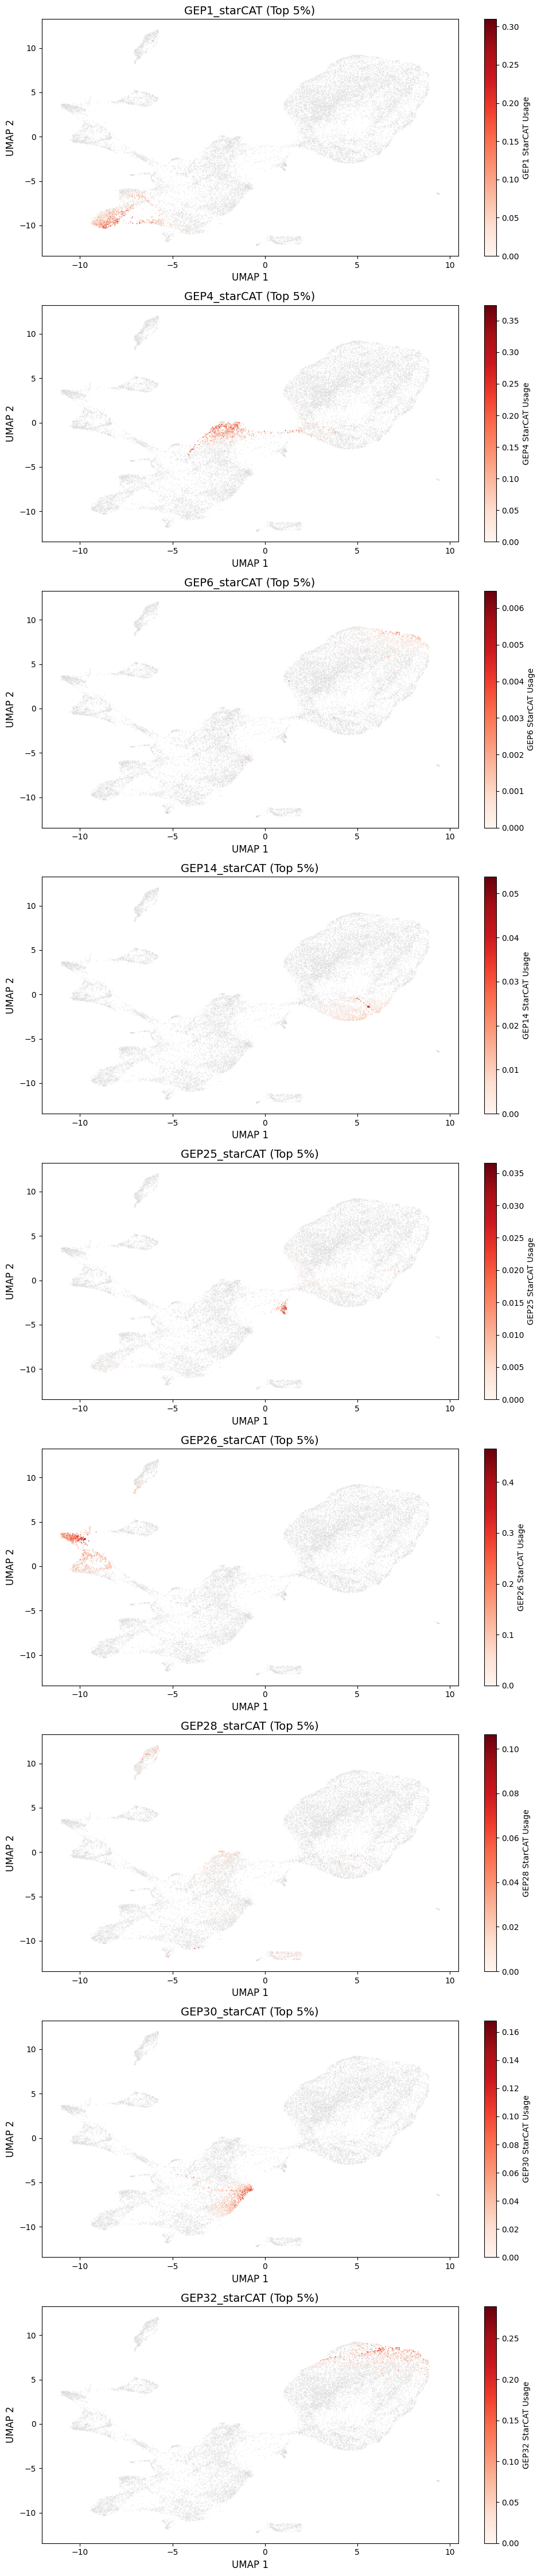

In [12]:
geps = ["1", "4", "6", "14", "25", "26", "28", "30", "32"]

fig, axes = plt.subplots(len(geps), 1, figsize=(10, len(geps) * 5))

for i, gep in enumerate(geps):
    percentile_95_starCAT = np.percentile(starCAT_coord[gep], 95)

    starCAT_coord[f"GEP{gep}_heat_starCAT"] = np.where(
        starCAT_coord[gep] >= percentile_95_starCAT, starCAT_coord[gep], np.nan
    )

    ax = axes[i]

    sns.scatterplot(
        data=starCAT_coord, x="umap_1", y="umap_2",
        color="lightgrey", alpha=0.5, s=1, ax=ax
    )

    scatter = sns.scatterplot(
        data=starCAT_coord, x="umap_1", y="umap_2",
        hue=f"GEP{gep}_heat_starCAT", palette="Reds",
        edgecolor=None, s=1, ax=ax, legend=False
    )

    norm = plt.Normalize(vmin=0, vmax=percentile_95_starCAT)
    sm = plt.cm.ScalarMappable(cmap="Reds", norm=norm)
    sm.set_array([])

    cbar = plt.colorbar(sm, ax=ax)
    cbar.set_label(f"GEP{gep} StarCAT Usage")

    ax.set_title(f"GEP{gep}_starCAT (Top 5%)", fontsize=14)
    ax.set_xlabel("UMAP 1", fontsize=12)
    ax.set_ylabel("UMAP 2", fontsize=12)

plt.tight_layout()
plt.show()
